In [2]:
import zarr
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import numpy as np

In [20]:
fe = zarr.open_group('/Users/mjablons/Documents/fe_line_i.zarr')
fe.tree()

/Users/mjablons/anaconda3/envs/astro/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at index.parquet is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


/
├── continuum (5577, 2001) float32
├── flux (5577, 2001) float32
├── global_index (5577,) int64
├── model_id (5577,) uint64
├── mu_selected (5577,) float32
├── mu_selected_index (5577,) int16
├── param_names (10,) <U32
├── parameter_columns
│   ├── a (5577,) float32
│   ├── c (5577,) float32
│   ├── feh (5577,) float32
│   ├── logg (5577,) float32
│   ├── n (5577,) float32
│   ├── o (5577,) float32
│   ├── r (5577,) float32
│   ├── s (5577,) float32
│   ├── teff (5577,) float32
│   └── vmicro (5577,) float32
├── params (5577, 10) float32
├── physics_hash () <U64
├── provenance
│   ├── atmosphere_manifest.json () object
│   ├── canonical_config.yaml () object
│   ├── environment.txt () object
│   ├── linelist_manifest.json () object
│   ├── software_manifest.json () object
│   └── synthesis_config.yaml () object
├── schema_version () <U16
└── wavelength (2001,) float32

In [21]:
# Show min and max for each parameter
for param_name in fe['param_names'][:]:
    param_data = fe['parameter_columns'][param_name][:]
    print(f"{param_name}: min={param_data.min():.4f}, max={param_data.max():.4f}")

teff: min=4000.0000, max=7000.0000
logg: min=0.0000, max=5.0000
feh: min=-2.5000, max=0.5000
vmicro: min=1.0000, max=3.0000
a: min=0.0000, max=0.0000
c: min=0.0000, max=0.0000
n: min=0.0000, max=0.0000
o: min=0.0000, max=0.0000
r: min=0.0000, max=0.0000
s: min=0.0000, max=0.0000


In [19]:
# Show unique values for teff, logg, feh, and vmicro
for param_name in ['teff', 'logg', 'feh', 'vmicro']:
    param_data = fe['parameter_columns'][param_name][:]
    unique_values = np.unique(param_data)
    step = np.diff(unique_values).min() if len(unique_values) > 1 else 0
    print(f"{param_name}: {len(unique_values)} unique values, step={step:.4f}")
    print(f"  Range: {unique_values.min():.4f} to {unique_values.max():.4f}")

teff: 13 unique values, step=250.0000
  Range: 4000.0000 to 7000.0000
logg: 11 unique values, step=0.5000
  Range: 0.0000 to 5.0000
feh: 13 unique values, step=0.2500
  Range: -2.5000 to 0.5000
vmicro: 3 unique values, step=1.0000
  Range: 1.0000 to 3.0000


In [22]:
np.unique(fe['mu_selected'][:])

array([0.124619, 0.222841, 0.340008, 0.468138, 0.598497, 0.722203,
       0.830825, 0.916958, 0.974726, 1.      ], dtype=float32)

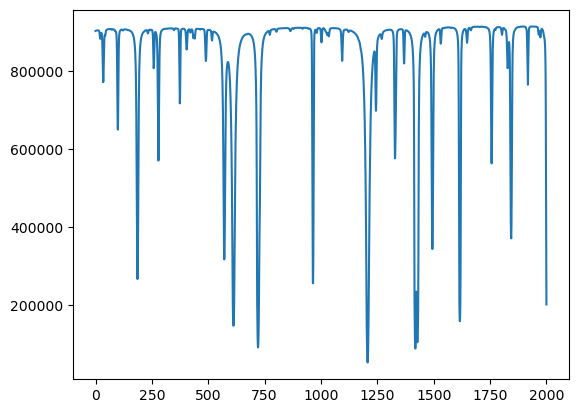

In [16]:
plt.plot(fe['flux'][:][0])